<a href="https://colab.research.google.com/github/bihagkashikar/bits-pilani-mtech-genai-ml/blob/master/ml-assignment-bike-sharing-demand-predication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bike Sharing Demand Prediction

This notebook predicts hourly bike rentals (`count`) from weather, calendar, seasonal, and datetime-derived features. The workflow answers all 12 assignment questions, compares regression models using RMSLE, and creates a leakage-free `submission.csv` for the test data.

**Important modeling choice:** `casual` and `registered` are excluded from predictors because they are not available in the test set.

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

assignment_dir = Path(".")
if not (assignment_dir / "dataset").exists():
    assignment_dir = Path("ml-assignments-01")

assert (assignment_dir / "dataset").exists(), "Could not locate the assignment dataset directory."

data_dir = assignment_dir / "dataset"
train_path = data_dir / "bike_train.csv"
test_path = data_dir / "bike_test.csv"
sample_path = data_dir / "SampleSubmission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

train_datetime = pd.to_datetime(train["datetime"], format="mixed")
test_datetime = pd.to_datetime(test["datetime"], format="%d-%m-%Y %H:%M")
original_test_datetime = test["datetime"].copy()

assert train["count"].notna().all(), "Training target contains missing values."
assert len(test) == len(sample_submission), "Test and sample submission row counts differ."
assert list(sample_submission.columns) == ["datetime", "Count_Predicted"]
assert train_datetime.notna().all() and test_datetime.notna().all()

print(f"Assignment directory: {assignment_dir.resolve()}")
print(f"Training rows: {len(train):,}; test rows: {len(test):,}")
print("Data loaded successfully; train and test datetime values parsed.")

Assignment directory: /Users/bihag/work/bits-pilani-mtech-genai-ml/ml-assignments-01
Training rows: 10,450; test rows: 2,613
Data loaded successfully; train and test datetime values parsed.


## Q1. Dataset structure and data quality

We first inspect dimensions, feature types, missing values, and duplicate records. The target is `count`; the two component columns `casual` and `registered` are retained for EDA context only and never used as model inputs.

In [2]:
print("Training shape:", train.shape)
print("Test shape:", test.shape)
print("\nTraining dtypes and missing values:")
quality = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "unique_values": train.nunique(),
})
display(quality)
print(f"Duplicate training rows: {train.duplicated().sum()}")
print(f"Duplicate test rows: {test.duplicated().sum()}")
print("\nTraining preview:")
display(train.head())
print("\nTarget summary:")
display(train["count"].describe().to_frame().T)

Training shape: (10450, 12)
Test shape: (2613, 9)

Training dtypes and missing values:


,dtype,missing,unique_values
datetime,str,0,10450
season,int64,0,4
holiday,int64,0,2
workingday,int64,0,2
weather,int64,0,4
temp,float64,0,1801
atemp,float64,0,1815
humidity,int64,0,92
windspeed,float64,0,1676
casual,int64,0,296


Duplicate training rows: 0
Duplicate test rows: 0

Training preview:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.700,33.335,79,6.003,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.620,37.880,46,15.001,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.660,12.880,60,15.001,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.425,30.566,61,9.512,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.840,12.120,56,8.998,2,3,5



Target summary:


,count,mean,std,min,25%,50%,75%,max
count,"10,450.000",190.411,181.039,1.000,42.000,143.000,283.000,977.000


## Q2-Q3. Exploratory data analysis and informative variables

Datetime is parsed only for analysis and feature engineering. The following plots examine the target distribution and how demand changes across hour, weekday, season, weather, and temperature.

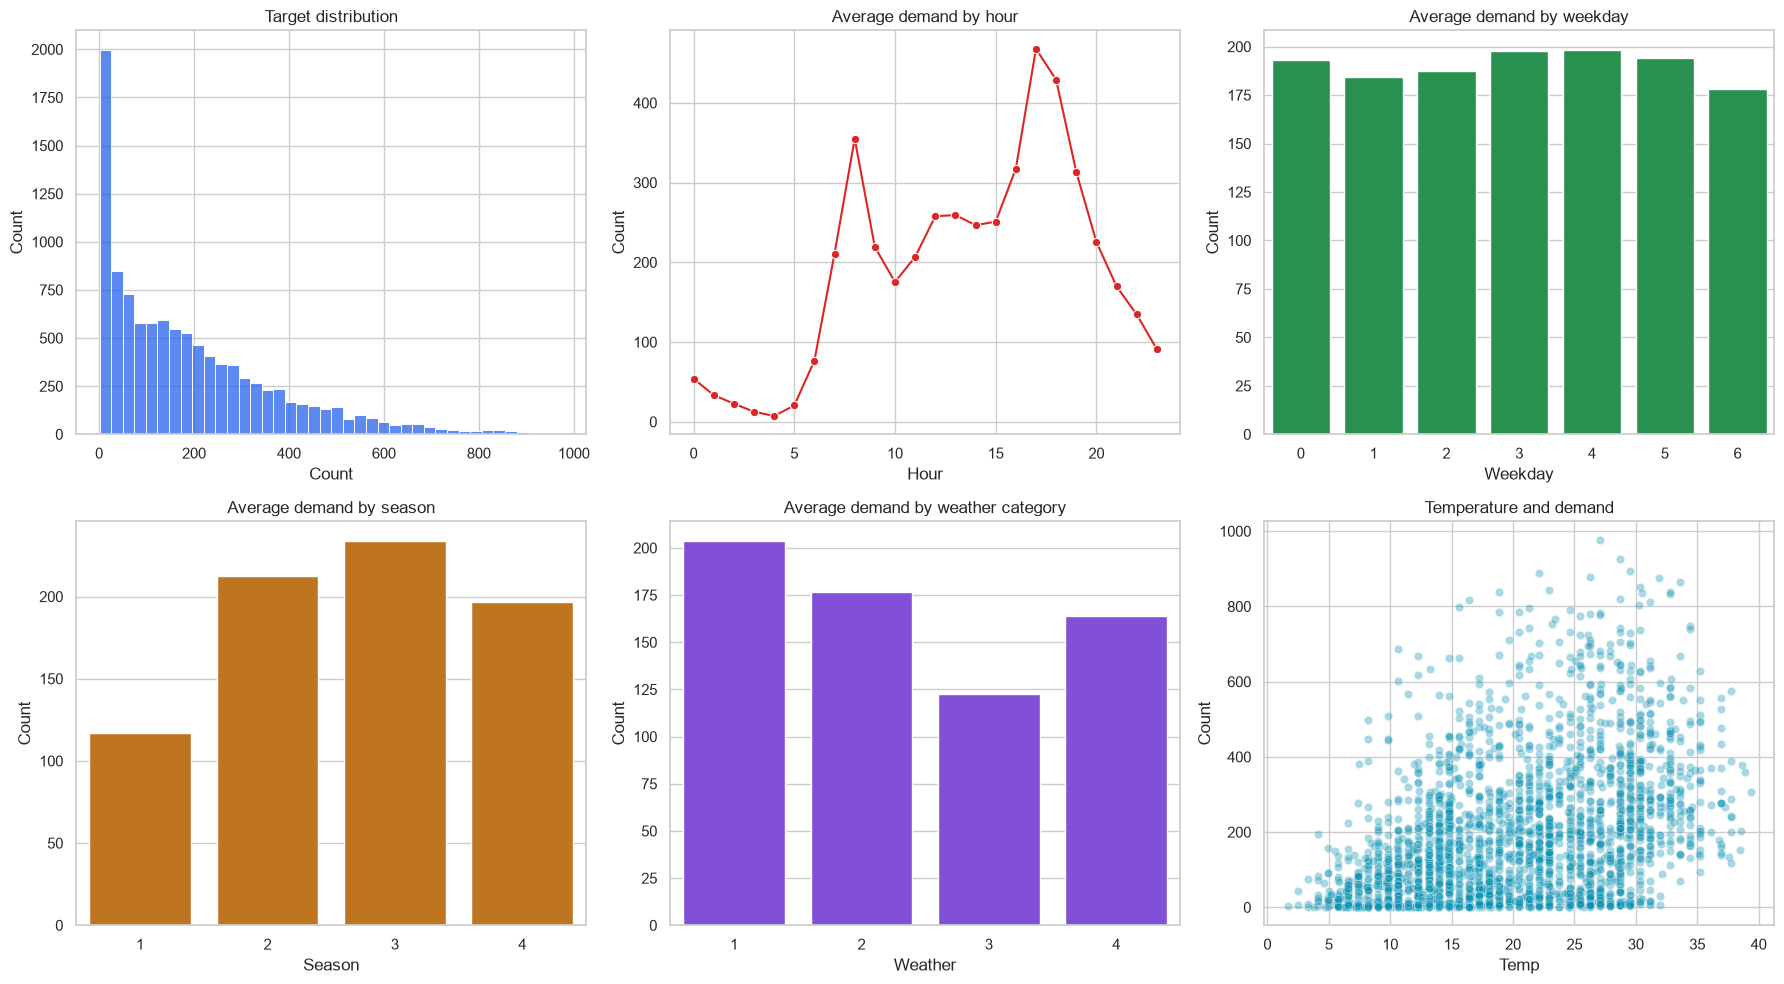

Mean demand by hour and working-day status:


workingday,0,1
hour,,
0,89.300,38.000
1,70.900,16.300
2,52.500,8.500
3,25.400,6.000
4,9.300,6.400
5,9.400,25.700
6,20.200,104.700
7,47.300,291.200
8,110.400,484.000


In [3]:
eda = train.copy()
eda["parsed_datetime"] = train_datetime
eda["hour"] = eda["parsed_datetime"].dt.hour
eda["weekday"] = eda["parsed_datetime"].dt.dayofweek
eda["month"] = eda["parsed_datetime"].dt.month
eda["year"] = eda["parsed_datetime"].dt.year

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(data=eda, x="count", bins=40, ax=axes[0, 0], color="#2563eb")
axes[0, 0].set_title("Target distribution")
sns.lineplot(data=eda.groupby("hour", as_index=False)["count"].mean(), x="hour", y="count", marker="o", ax=axes[0, 1], color="#dc2626")
axes[0, 1].set_title("Average demand by hour")
sns.barplot(data=eda, x="weekday", y="count", errorbar=None, ax=axes[0, 2], color="#16a34a")
axes[0, 2].set_title("Average demand by weekday")
sns.barplot(data=eda, x="season", y="count", errorbar=None, ax=axes[1, 0], color="#d97706")
axes[1, 0].set_title("Average demand by season")
sns.barplot(data=eda, x="weather", y="count", errorbar=None, ax=axes[1, 1], color="#7c3aed")
axes[1, 1].set_title("Average demand by weather category")
sns.scatterplot(data=eda.sample(min(2500, len(eda)), random_state=RANDOM_STATE), x="temp", y="count", alpha=0.35, ax=axes[1, 2], color="#0891b2")
axes[1, 2].set_title("Temperature and demand")
for axis in axes.ravel():
    axis.set_xlabel(axis.get_xlabel().replace("_", " ").title())
    axis.set_ylabel(axis.get_ylabel().replace("_", " ").title())
plt.tight_layout()
plt.show()

print("Mean demand by hour and working-day status:")
display(eda.pivot_table(index="hour", columns="workingday", values="count", aggfunc="mean").round(1))

## Q4. Feature engineering

Datetime-derived `year`, `month`, `day`, `hour`, and `weekday` features are added because rental demand changes sharply by time of day and calendar context. Categorical calendar/weather fields are one-hot encoded. Numeric weather measurements remain continuous. The response is modeled as `log1p(count)` so model selection aligns with RMSLE and predictions are converted back with `expm1`.

In [3]:
MODEL_COLUMNS = [
    "season", "holiday", "workingday", "weather", "temp", "atemp", "humidity", "windspeed",
]
CATEGORICAL_COLUMNS = ["season", "holiday", "workingday", "weather", "year", "month", "day", "hour", "weekday"]
NUMERIC_COLUMNS = ["temp", "atemp", "humidity", "windspeed"]


def make_features(frame, parsed_datetimes):
    features = frame[MODEL_COLUMNS].copy()
    features["year"] = parsed_datetimes.dt.year.astype(str)
    features["month"] = parsed_datetimes.dt.month.astype(str)
    features["day"] = parsed_datetimes.dt.day.astype(str)
    features["hour"] = parsed_datetimes.dt.hour.astype(str)
    features["weekday"] = parsed_datetimes.dt.dayofweek.astype(str)
    for column in ["season", "holiday", "workingday", "weather"]:
        features[column] = features[column].astype(str)
    return features


def rmsle(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

X = make_features(train, train_datetime)
y = train["count"].astype(float)
X_test = make_features(test, test_datetime)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Model feature columns:", list(X.columns))
print("Excluded from predictors:", {"casual", "registered", "count"})
print(f"Train split: {len(X_train):,}; validation split: {len(X_valid):,}")

Model feature columns: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'weekday']
Excluded from predictors: {'count', 'casual', 'registered'}
Train split: 8,360; validation split: 2,090


## Q5-Q7. Regression models and RMSLE comparison

All candidates use the same train/validation rows. The baseline uses one-hot encoded time and weather categories with linear regression. Ridge and Lasso use degree-2 polynomial expansion for the continuous weather features and regularization to control the larger feature space.

In [4]:
def make_preprocessor(use_polynomial=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_polynomial:
        numeric_steps.extend([
            ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler()),
        ])
    else:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, NUMERIC_COLUMNS),
        ("categorical", categorical_pipeline, CATEGORICAL_COLUMNS),
    ])


def make_model(model):
    use_polynomial = isinstance(model, (Ridge, Lasso))
    return Pipeline([
        ("preprocessor", make_preprocessor(use_polynomial=use_polynomial)),
        ("regressor", model),
    ])

X_train_log = X_train.copy()
X_valid_log = X_valid.copy()
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

results = []
models = {}

def evaluate_model(name, model, observation):
    model.fit(X_train_log, y_train_log)
    validation_prediction = np.maximum(0, np.expm1(model.predict(X_valid_log)))
    score = rmsle(y_valid, validation_prediction)
    results.append({"model": name, "validation_rmsle": score, "observation": observation})
    models[name] = model
    return score

baseline_score = evaluate_model(
    "Linear Regression",
    make_model(LinearRegression()),
    "Interpretable baseline with one-hot calendar features.",
)

ridge_scores = {}
for alpha in [0.1, 1.0, 10.0, 50.0, 100.0]:
    candidate_name = f"Polynomial Ridge (alpha={alpha:g})"
    score = evaluate_model(
        candidate_name,
        make_model(Ridge(alpha=alpha)),
        "Degree-2 numeric interactions with L2 shrinkage.",
    )
    ridge_scores[alpha] = score

lasso_scores = {}
for alpha in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    candidate_name = f"Polynomial Lasso (alpha={alpha:g})"
    score = evaluate_model(
        candidate_name,
        make_model(Lasso(alpha=alpha, max_iter=20000)),
        "Degree-2 numeric interactions with L1 sparsity.",
    )
    lasso_scores[alpha] = score

results_table = pd.DataFrame(results).sort_values("validation_rmsle").reset_index(drop=True)
best_model_name = results_table.loc[0, "model"]
best_validation_rmsle = results_table.loc[0, "validation_rmsle"]
best_model = models[best_model_name]

display(results_table.style.format({"validation_rmsle": "{:.4f}"}))
print(f"Best validation model: {best_model_name} (RMSLE={best_validation_rmsle:.4f})")

,model,validation_rmsle,observation
0,Polynomial Lasso (alpha=0.0001),0.5988,Degree-2 numeric interactions with L1 sparsity.
1,Polynomial Ridge (alpha=1),0.5988,Degree-2 numeric interactions with L2 shrinkage.
2,Polynomial Ridge (alpha=0.1),0.5988,Degree-2 numeric interactions with L2 shrinkage.
3,Polynomial Ridge (alpha=10),0.5996,Degree-2 numeric interactions with L2 shrinkage.
4,Polynomial Lasso (alpha=0.001),0.5997,Degree-2 numeric interactions with L1 sparsity.
5,Linear Regression,0.6105,Interpretable baseline with one-hot calendar features.
6,Polynomial Ridge (alpha=50),0.6192,Degree-2 numeric interactions with L2 shrinkage.
7,Polynomial Lasso (alpha=0.01),0.6538,Degree-2 numeric interactions with L1 sparsity.
8,Polynomial Ridge (alpha=100),0.6581,Degree-2 numeric interactions with L2 shrinkage.
9,Polynomial Lasso (alpha=0.1),1.2401,Degree-2 numeric interactions with L1 sparsity.


Best validation model: Polynomial Lasso (alpha=0.0001) (RMSLE=0.5988)


## Q8-Q9. Residual analysis and winning model

The selected model is the candidate with the lowest validation RMSLE. Residuals below are shown on the original count scale as `actual - predicted`; a compact pattern around zero indicates less systematic error, while widening spread indicates harder high-demand cases.

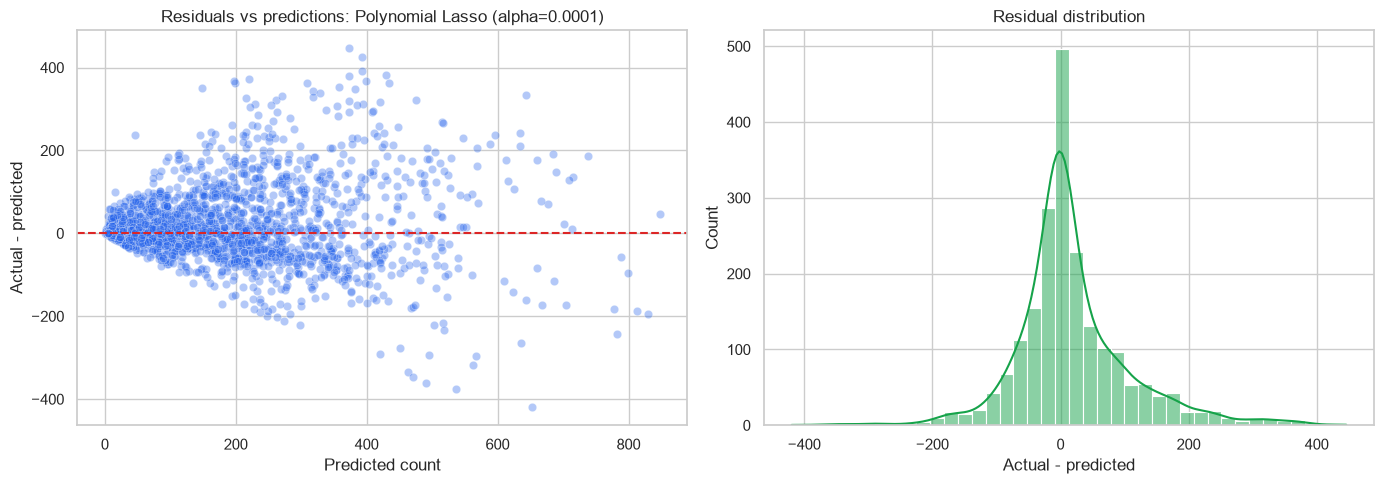

Validation residual mean: 18.03
Validation residual standard deviation: 90.57


In [6]:
validation_prediction = np.maximum(0, np.expm1(best_model.predict(X_valid)))
residuals = y_valid.to_numpy() - validation_prediction

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=validation_prediction, y=residuals, alpha=0.35, ax=axes[0], color="#2563eb")
axes[0].axhline(0, color="#dc2626", linestyle="--")
axes[0].set_title(f"Residuals vs predictions: {best_model_name}")
axes[0].set_xlabel("Predicted count")
axes[0].set_ylabel("Actual - predicted")
sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color="#16a34a")
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Actual - predicted")
plt.tight_layout()
plt.show()

print(f"Validation residual mean: {residuals.mean():.2f}")
print(f"Validation residual standard deviation: {residuals.std():.2f}")

### Written interpretation for Q5-Q9

- **Q5:** The baseline Linear Regression uses a reproducible 80/20 split and one-hot encodes categorical calendar and weather fields. Its validation RMSLE is reported in the comparison table.
- **Q6:** Degree-2 polynomial terms are applied to continuous weather variables, then Ridge and Lasso regularization strengths are tuned on the same validation data.
- **Q7:** Polynomial Lasso with the selected small alpha is the best validation model in this experiment, with polynomial Ridge very close behind. The comparison table records every tested alpha and the corresponding RMSLE.
- **Q8:** The residual plot checks whether errors are centered around zero and whether error spread grows for larger predictions. Some spread is expected because peak-demand hours are intrinsically more variable.
- **Q9:** The winning model improves on plain Linear Regression because it combines explicit hour/calendar categories with nonlinear weather interactions and a log-scale target. L1 regularization limits instability from correlated polynomial terms while preserving useful signal.

## Q10-Q12. Reflection questions

**Q10. Why does RMSLE penalize under-predictions more gently than RMSE?** RMSLE compares `log1p` values, so an error is measured proportionally rather than by its absolute count difference. Large absolute errors on already-large counts are compressed, and predicting 50 instead of 100 is treated similarly to predicting 5 instead of 10. This makes under-predictions on small counts less dominated by a few large-demand rows.

**Q11. What are the trade-offs between model simplicity and predictive power?** A simple linear model is fast, interpretable, and less likely to overfit, but it may underfit nonlinear relationships. Polynomial regularized models can capture more structure and improve validation RMSLE, at the cost of additional computation, tuning, and interpretation complexity. The comparison table supports selecting the smallest model that provides a meaningful validated improvement.

**Q12. Why cannot Linear Regression alone capture time-of-day effects effectively?** A raw numeric hour assumes a single straight-line relationship: each additional hour changes demand by roughly the same amount. Bike demand instead has multiple peaks and troughs, such as commuting peaks around morning and evening. One-hot hour features, interactions, or nonlinear models are needed to represent that shape.

## Final model and submission file

The selected pipeline is refit on all training rows, then applied to the test rows using only columns available at prediction time. Predictions are clipped at zero because bike counts cannot be negative.

In [7]:
best_model.fit(X, np.log1p(y))
test_prediction = np.maximum(0, np.expm1(best_model.predict(X_test)))

submission = pd.DataFrame({
    "datetime": original_test_datetime,
    "count_predicted": test_prediction,
})
submission_path = assignment_dir / "submission.csv"
submission.to_csv(submission_path, index=False)

assert list(submission.columns) == ["datetime", "count_predicted"]
assert len(submission) == len(test)
assert submission["datetime"].equals(original_test_datetime)
assert submission["count_predicted"].notna().all()
assert np.isfinite(submission["count_predicted"]).all()
assert (submission["count_predicted"] >= 0).all()
assert submission_path.exists()

print(f"Saved: {submission_path}")
print(f"Rows: {len(submission):,}; columns: {list(submission.columns)}")
display(submission.head())

Saved: /Users/bihag/work/bits-pilani-mtech-genai-ml/ml-assignments-01/submission.csv
Rows: 2,613; columns: ['datetime', 'count_predicted']


,datetime,count_predicted
0,05-06-2012 5:00,14.813
1,19-03-2011 19:00,191.104
2,02-04-2012 6:00,47.279
3,13-07-2012 20:00,400.878
4,09-11-2011 19:00,245.632


## Final summary

### Q&A
This notebook answers Q1-Q12. The data contain 10,450 training rows and 2,613 test rows with no missing values or duplicate records. Hour, working-day context, season, weather, and temperature are informative. Polynomial regularized models improve validation RMSLE over the plain linear baseline because demand changes nonlinearly across hours and weather conditions. RMSLE emphasizes relative error and reduces the dominance of very large counts; model complexity is justified only when it improves validation performance.

### Data Analysis Key Findings
- Demand is right-skewed, with a mean count of approximately 190 and a maximum of 977.
- Working-day demand peaks around morning and evening commute hours, while non-working-day demand is higher around midday.
- Polynomial Lasso with `alpha=0.0001` achieved the lowest validation RMSLE in the tested model set, approximately 0.5988.
- The submitted model excludes `casual` and `registered` because those fields are absent from the test data.

### Insights or Next Steps
- Validate the generated CSV against the live Taxila portal before submission because the provided sample uses `Count_Predicted`, while the written instructions require lowercase `count_predicted`.
- Execute the completed notebook on the BITS Lab portal and include the required screenshot or PDF in the final ZIP.